In [12]:
#1. Import Libraries & Load Data (ตรวจสอบโครงสร้างข้อมูล)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าธีมกราฟ
sns.set_theme(style="whitegrid")

# 1. โหลดข้อมูล
df = pd.read_csv('Crop_recommendation.csv')

print(f"ขนาดของ Dataset: {df.shape[0]} แถว, {df.shape[1]} คอลัมน์")
print("\n--- ข้อมูลโครงสร้างและประเภทข้อมูล ---")
print(df.info())

ขนาดของ Dataset: 2200 แถว, 8 คอลัมน์

--- ข้อมูลโครงสร้างและประเภทข้อมูล ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


In [14]:
#2. Data Cleaning & Preprocessing (ทำความสะอาดข้อมูล)

In [15]:
# 1. ตัดช่องว่างส่วนเกินในคอลัมน์ข้อความ (label)
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)
print("1. ตัดช่องว่างส่วนเกินในคอลัมน์ Text เรียบร้อยแล้ว")

# 2. ตรวจสอบและลบข้อมูลซ้ำ
initial_rows = len(df)
df = df.drop_duplicates()
print(f"2. ลบข้อมูลซ้ำ: ตัดออก {initial_rows - len(df)} แถว (เหลือ {len(df)} แถว)")

# 3. ตรวจสอบ Missing Values ในแต่ละคอลัมน์
print("\n3. ตรวจสอบค่าที่สูญหาย (Missing Values):")
print(df.isnull().sum())

# 4. สรุปรายชื่อและจำนวนชนิดพืชในชุดข้อมูล
print(f"\n4. จำนวนพืชทั้งหมด: {df['label'].nunique()} ชนิด")
print("รายชื่อพืชใน Dataset:", df['label'].unique())

# 5. Audit Check ภาพรวม
print("\n--- Final Data Health Check Summary ---")
print("Explicit Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("\nประเภทข้อมูลย่อย:")
print(df.dtypes)

# 6. Export ไฟล์ที่ทำความสะอาดแล้ว
df.to_csv('crop_recommendation_cleaned.csv', index=False)
print("\nบันทึกไฟล์ 'crop_recommendation_cleaned.csv' สำเร็จ!")

1. ตัดช่องว่างส่วนเกินในคอลัมน์ Text เรียบร้อยแล้ว
2. ลบข้อมูลซ้ำ: ตัดออก 0 แถว (เหลือ 2200 แถว)

3. ตรวจสอบค่าที่สูญหาย (Missing Values):
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

4. จำนวนพืชทั้งหมด: 22 ชนิด
รายชื่อพืชใน Dataset: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

--- Final Data Health Check Summary ---
Explicit Missing Values: 0
Duplicate Rows: 0

ประเภทข้อมูลย่อย:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

บันทึกไฟล์ 'crop_recommendation_cleaned.csv' สำเร็จ!


In [28]:
#3. Exploratory Data Analysis (EDA) & Summary Statistics

--- สถิติสรุปตัวแปรเชิงตัวเลข ---
                   mean     median        std        min         max
N             50.551818  37.000000  36.917334   0.000000  140.000000
P             53.362727  51.000000  32.985883   5.000000  145.000000
K             48.149091  32.000000  50.647931   5.000000  205.000000
temperature   25.616244  25.598693   5.063749   8.825675   43.675493
humidity      71.481779  80.473146  22.263812  14.258040   99.981876
ph             6.469480   6.425045   0.773938   3.504752    9.935091
rainfall     103.463655  94.867624  54.958389  20.211267  298.560117

--- ค่าเฉลี่ยปัจจัยทางกายภาพจำแนกตามชนิดพืช (แสดง 10 ชนิดแรก) ---
                  N       P       K  temperature   humidity        ph  \
label                                                                   
apple         20.80  134.22  199.89    22.630942  92.333383  5.929663   
banana       100.23   82.01   50.05    27.376798  80.358123  5.983893   
blackgram     40.02   67.47   19.24    29.973340  65.11

C:\Users\Admin\AppData\Local\Temp\ipykernel_15828\3104025679.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=df, ax=axes[0, 0], order=df['label'].value_counts().index, palette='viridis')


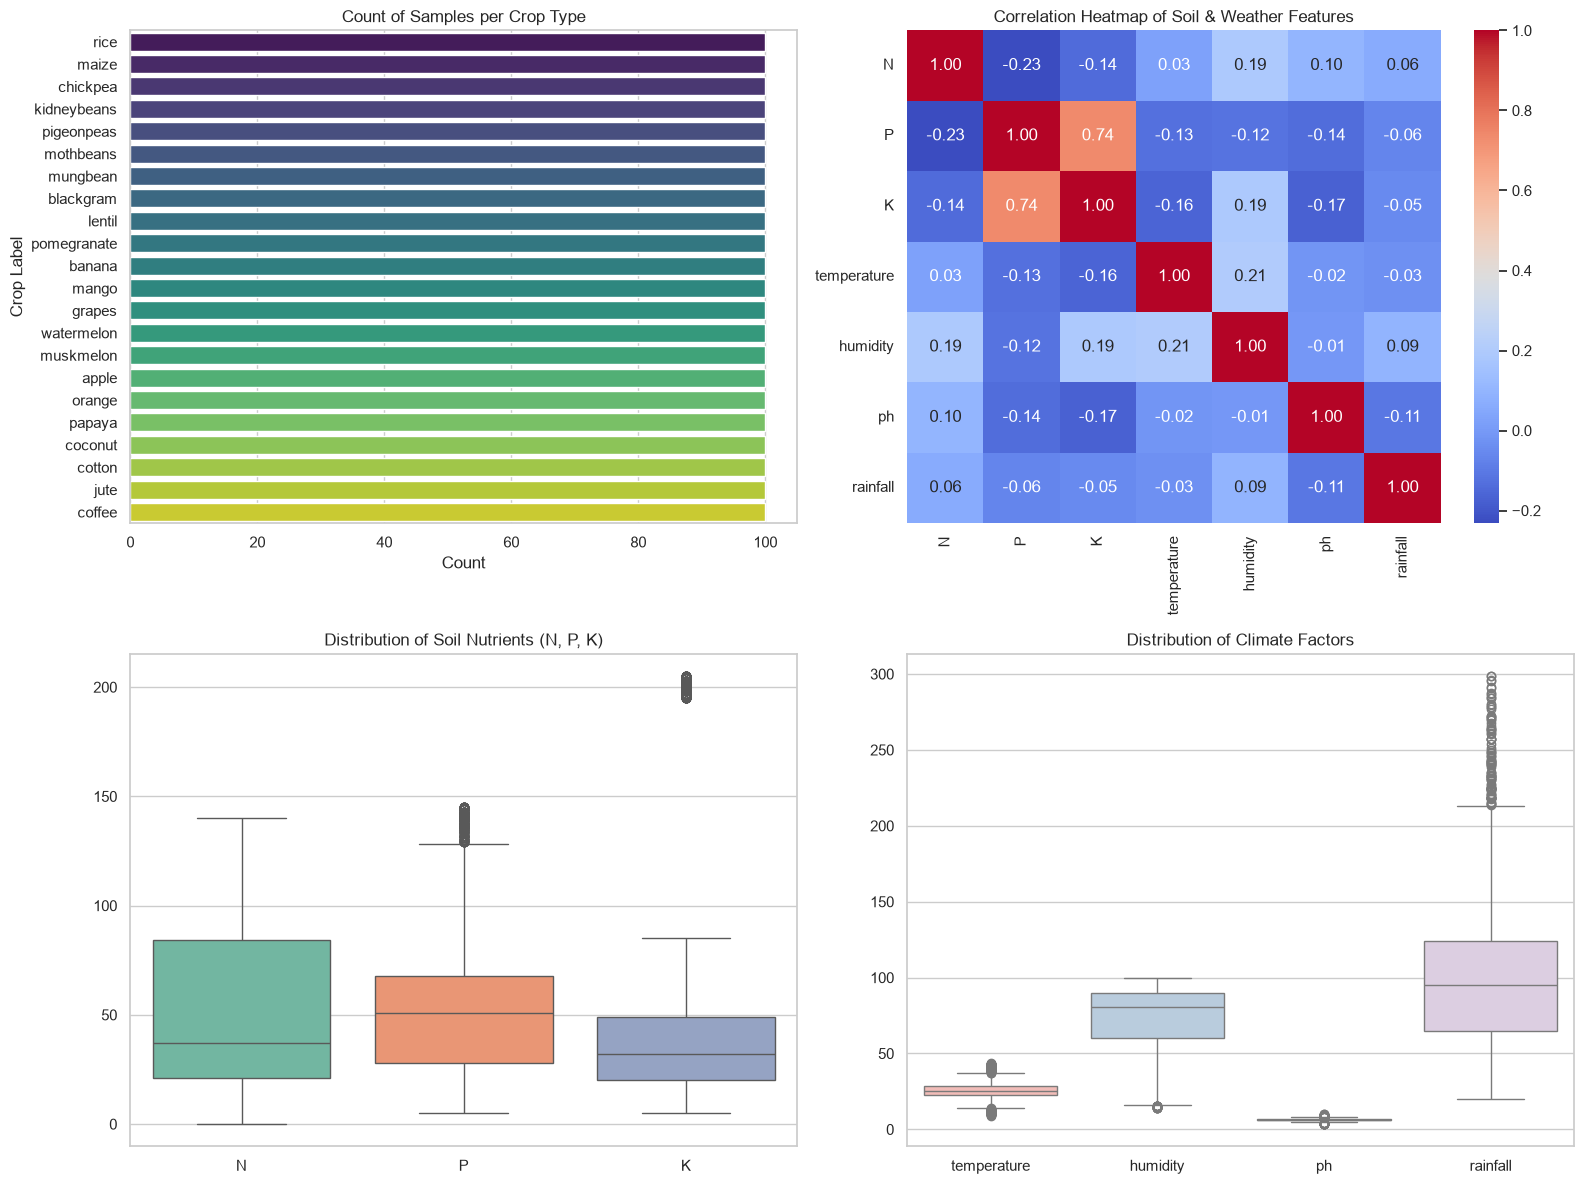

In [16]:
# 1. สถิติสรุปของตัวแปรเชิงตัวเลขทั้งหมด (N, P, K, temperature, humidity, ph, rainfall)
print("--- สถิติสรุปตัวแปรเชิงตัวเลข ---")
num_summary = df.describe().T[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'median'})
print(num_summary)

# 2. ค่าเฉลี่ยของธาตุอาหารและสภาพอากาศ แยกตามชนิดพืช (label)
print("\n--- ค่าเฉลี่ยปัจจัยทางกายภาพจำแนกตามชนิดพืช (แสดง 10 ชนิดแรก) ---")
crop_means = df.groupby('label').mean()
print(crop_means.head(10))

# 3. การสร้างกราฟวิเคราะห์ข้อมูล (Visualizations)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# กราฟ 1: จำนวนตัวอย่างข้อมูลของพืชแต่ละชนิด (Class Distribution)
sns.countplot(y='label', data=df, ax=axes[0, 0], order=df['label'].value_counts().index, palette='viridis')
axes[0, 0].set_title('Count of Samples per Crop Type')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Crop Label')

# กราฟ 2: ความสัมพันธ์ระหว่างตัวแปรเชิงตัวเลข (Correlation Heatmap)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 1])
axes[0, 1].set_title('Correlation Heatmap of Soil & Weather Features')

# กราฟ 3: การกระจายตัวของธาตุอาหารในดิน (N, P, K)
sns.boxplot(data=df[['N', 'P', 'K']], ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Distribution of Soil Nutrients (N, P, K)')

# กราฟ 4: การกระจายตัวของปัจจัยสภาพแวดล้อม (temperature, humidity, ph, rainfall)
sns.boxplot(data=df[['temperature', 'humidity', 'ph', 'rainfall']], ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Distribution of Climate Factors')

plt.tight_layout()
plt.show()